In [5]:
import matplotlib.pyplot as plt

In [6]:
# ==============================
# S 区域（矩形组合）
# ==============================
S_rects = [
    [(0, 9), (4, 10)],  # 上横
    [(0, 4), (1, 9)],  # 上竖
    [(0, 4), (4, 5)],  # 中横
    [(3, 0), (4, 5)],  # 下竖
    [(0, 0), (4, 1)],  # 下横
]

# ==============================
# C 区域（矩形组合）
# ==============================
C_rects = [
    [(0, 9), (4, 10)],  # 上横
    [(0, 0), (4, 1)],  # 下横
    [(0, 1), (1, 9)],  # 左竖
]
# ==============================
# A 区域（矩形组合，上下封口 + 中横）
# ==============================
A_rects = [
    [(0, 0), (1, 10)],  # 左竖
    [(3, 0), (4, 10)],  # 右竖
    [(0, 9), (4, 10)],  # 上横（封口）
    [(0, 4), (4, 5)],  # 中横
]

# ==============================
# I 区域（矩形组合）
# ==============================
I_rects = [
    [(0, 0), (4, 1)],  # 下横
    [(1.5, 1), (2.5, 9)],  # 中竖
    [(0, 9), (4, 10)],  # 上横
]
# ==============================
# 偏移量，保证四个字母水平排列
# ==============================
x_offsets = [0, 6, 12, 18]  # 每个字母向右偏移

letters_rects = [S_rects, C_rects, A_rects, I_rects]
letters_colors = ["red", "purple", "green", "blue"]
letters_labels = ["S", "C", "A", "I"]

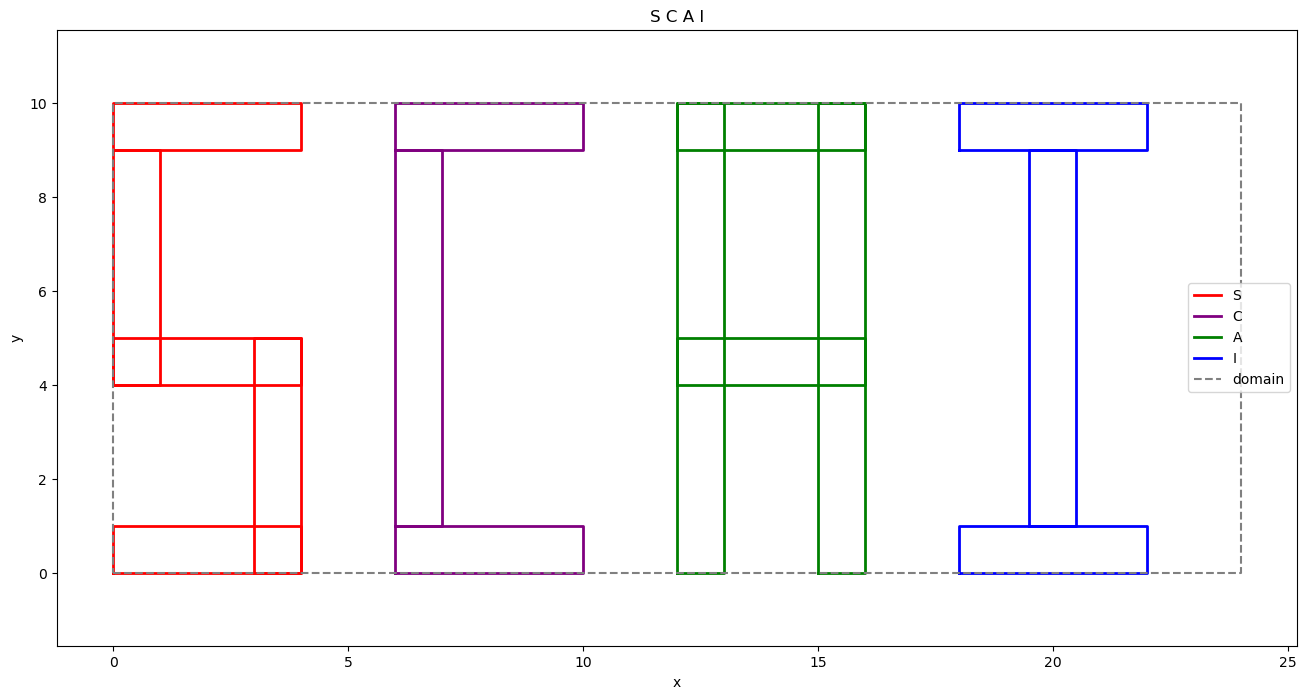

In [7]:
# ==============================
# 绘制函数
# ==============================
plt.figure(figsize=(16, 8))

for i, rects in enumerate(letters_rects):
    offset = x_offsets[i]
    color = letters_colors[i]
    label = letters_labels[i]
    for j, rect in enumerate(rects):
        x0, y0 = rect[0]
        x1, y1 = rect[1]
        plt.plot(
            [x0 + offset, x1 + offset, x1 + offset, x0 + offset, x0 + offset],
            [y0, y0, y1, y1, y0],
            color=color,
            linewidth=2,
            label=label if j == 0 else "",
        )

# 绘制 domain 边框（整体框）
plt.plot(
    [0, 24, 24, 0, 0], [0, 0, 10, 10, 0], "--", color="gray", label="domain"
)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("S C A I")
plt.legend()
plt.show()

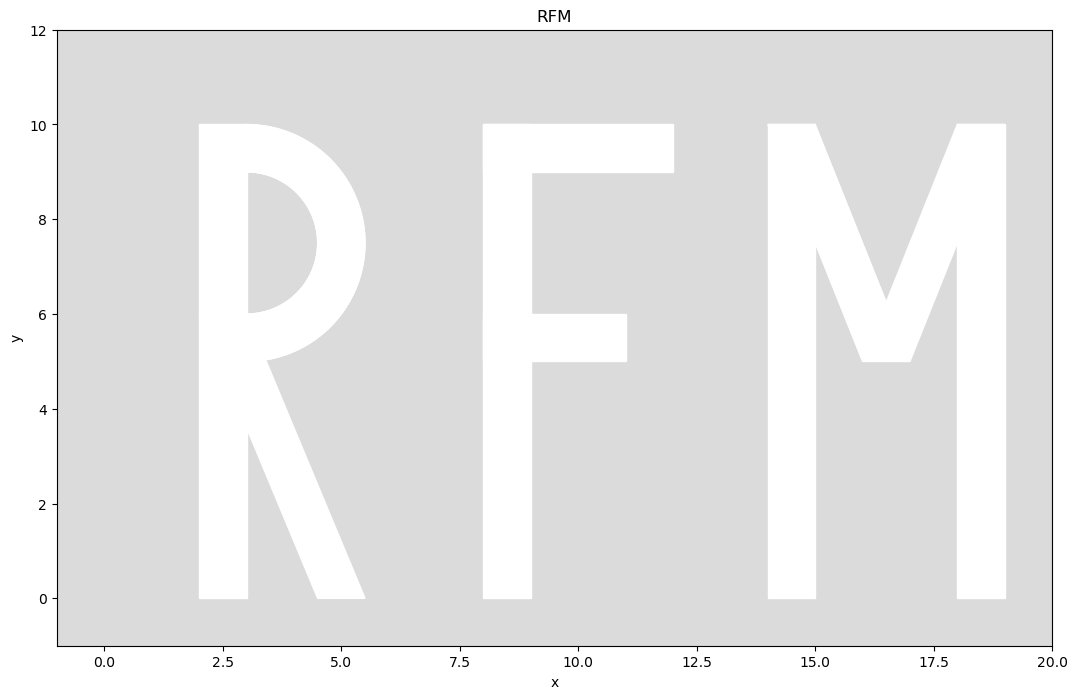

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(16, 8))

# ======================
# 参数
# ======================
width = 1  # 矩形笔画宽度
height = 10  # 字母高度

# ----------------------
# 大区域
# ----------------------
domain = patches.Rectangle(
    (-1, -1), 22, 14, color='lightgray', alpha=0.8, zorder=0)
ax.add_patch(domain)

# ----------------------
# R 字母（挖洞）
# ----------------------
offset_R = 2
# 左竖
r_left = patches.Rectangle((offset_R, 0), width,
                           height, color='white', zorder=2)
ax.add_patch(r_left)
# 半圆环（右上弧）
theta = np.linspace(-np.pi/2, np.pi/2, 100)
r = 2
x_arc = r*np.cos(theta) + width + offset_R
y_arc = r*np.sin(theta) + height - r - 0.5
for xi, yi in zip(x_arc, y_arc):
    ax.add_patch(patches.Circle((xi, yi), radius=0.5, color='white', zorder=2))
# 右下撇（平行四边形）
par_R = np.array([[offset_R, height - 2 * r],
                  [offset_R + 1, height - 2 * r],
                  [width+offset_R + 2.5, 0],
                  [width+offset_R + 1.5, 0]])
ax.add_patch(patches.Polygon(par_R, color='white', zorder=2))

# ----------------------
# F 字母（挖洞）
# ----------------------
offset_F = 8
# 左竖
ax.add_patch(patches.Rectangle((0+offset_F, 0),
             width, height, color='white', zorder=2))
# 上横
ax.add_patch(patches.Rectangle((0+offset_F, 9),
             4, width, color='white', zorder=2))
# 中横
ax.add_patch(patches.Rectangle((0+offset_F, 5),
             3, width, color='white', zorder=2))

# ----------------------
# M 字母（挖洞）
# ----------------------
offset_M = 14
# 左右竖
ax.add_patch(patches.Rectangle((offset_M, 0),
             width, height, color='white', zorder=2))
ax.add_patch(patches.Rectangle((4+offset_M, 0),
             width, height, color='white', zorder=2))
# 中间折线
par_M1 = np.array([[offset_M, 10], [2+offset_M, 5],
                  [2+offset_M+width, 5], [offset_M+width, 10]])
par_M2 = np.array([[2+offset_M, 5], [2+offset_M+width*2, 10],
                  [2+offset_M+width*3, 10], [2+offset_M+width, 5]])
ax.add_patch(patches.Polygon(par_M1, color='white', zorder=2))
ax.add_patch(patches.Polygon(par_M2, color='white', zorder=2))


ax.set_aspect('equal')
ax.set_xlim(-1, 20)
ax.set_ylim(-1, 12)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("RFM")
plt.show()